# 🏠 UrbanNest Analytics — European Housing Intelligence
## Notebook 3: Hypothesis Testing
**Dataset:** Italian Rental Listings (Cleaned)
**Analyst:** Sahil Changotra
**Method:** pandas + scipy.stats + matplotlib + seaborn

## 📋 Overview
This notebook tests 3 business hypotheses about the Italian rental market
using statistical tests on the cleaned HousingAnywhere dataset.

| # | Hypothesis | Test Used | Why |
|---|---|---|---|
| H1 | Furnished listings price > Unfurnished | Mann-Whitney U | Non-normal distribution, two independent groups |
| H2 | Milan median price > Overall market median | One-sample t-test | One city vs fixed market value |
| H3 | Private rooms price < Studios | Mann-Whitney U | Two independent groups, non-normal |

**Decision rule:** p-value < 0.05 → reject null hypothesis → difference is statistically significant

In [3]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
# Load Data

df = pd.read_csv('../data/ha_data_clean.csv')

In [5]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nPrice stats:")
print(df['price'].describe().round(2))

Shape: (8874, 14)
Columns: ['city', 'category', 'country_code', 'created_at', 'price', 'furnished', 'total_size', 'registration_possible', 'washing_machine', 'tv', 'balcony', 'garden', 'terrace', 'is_price_outlier']

Price stats:
count      8874.00
mean        641.91
std        1250.38
min          10.00
25%         286.00
50%         400.00
75%         648.00
max      100000.00
Name: price, dtype: float64


## 🧪 H1: Furnished vs Unfurnished Price
**Null hypothesis (H0):** Furnished and unfurnished listings have the same price
**Alternative hypothesis (H1):** Furnished listings are priced higher than unfurnished
**Test:** Mann-Whitney U (one-tailed)
**Why Mann-Whitney:** Price distribution is skewed — not normally distributed

In [6]:
# filter groups
furnished = df[df['furnished']=='yes']['price'].dropna()
unfurnished = df[df['furnished']=='no']['price'].dropna()

print(f"Furnished listings: n={len(furnished)},median=£{furnished.median():.2f},mean=£{furnished.mean():.2f}")
print(f"Unfurnished listings: n={len(unfurnished)}, median=£{unfurnished.median():.2f}, mean=£{unfurnished.mean():.2f}")



Furnished listings: n=4723,median=£450.00,mean=£676.58
Unfurnished listings: n=821, median=£430.00, mean=£490.34


In [7]:
# Mann-Whitney U test (one-tailed : furnished > unfurnished)

stat, p_value = stats.mannwhitneyu(furnished, unfurnished, alternative='greater')

print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"P-value (one-tailed): {p_value:.6f}")

if p_value < 0.05:
    print("✅ Result: REJECT H0 — Furnished listings are significantly MORE expensive")
else:
    print("❌ Result: FAIL TO REJECT H0 — No significant difference")    


Mann-Whitney U statistic: 2124332.50
P-value (one-tailed): 0.000006
✅ Result: REJECT H0 — Furnished listings are significantly MORE expensive


#### H1 Visualisation

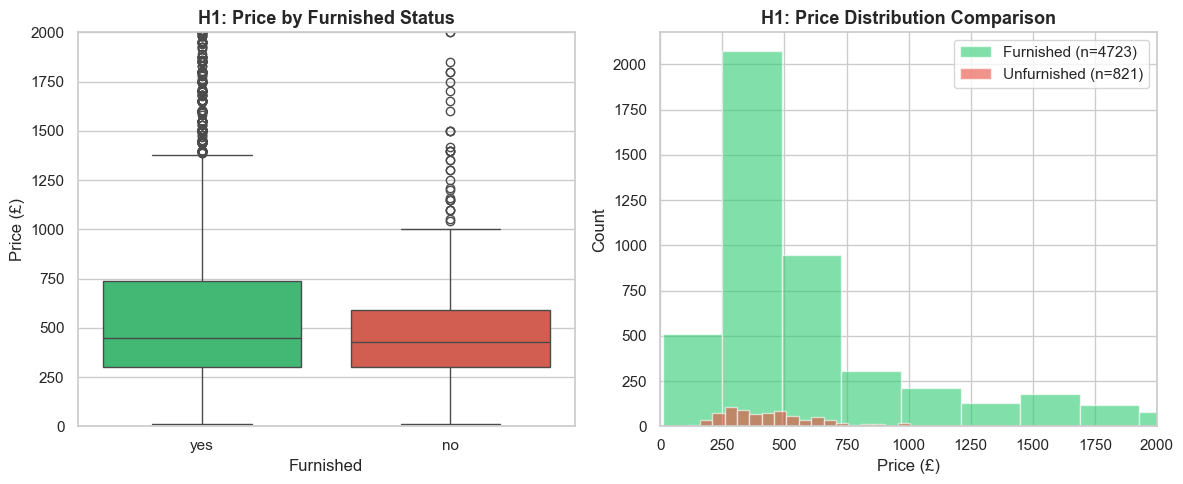

Chart saved.


In [8]:
fig, axes = plt.subplots(1,2,figsize = (12,5))

# Box plot
sns.boxplot(data=df[df['furnished'].isin(['yes','no'])],
            x='furnished', y='price',
            order=['yes','no'],
            hue='furnished',
            palette=['#2ecc71','#e74c3c'],
            ax=axes[0])
axes[0].set_title('H1: Price by Furnished Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Furnished')
axes[0].set_ylabel('Price (£)')
axes[0].set_ylim(0, 2000)

# Density plot
axes[1].hist(furnished, bins=50, alpha=0.6, color='#2ecc71', label=f'Furnished (n={len(furnished)})')
axes[1].hist(unfurnished, bins=50, alpha=0.6, color='#e74c3c', label=f'Unfurnished (n={len(unfurnished)})')
axes[1].set_title('H1: Price Distribution Comparison', fontsize=13, fontweight= 'bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 2000)
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/h1_furnished_vs_unfurnished.png',dpi=150,bbox_inches='tight')
plt.show()
print("Chart saved.")

## 🧪 H2: Milan Price vs Market Median
**Null hypothesis (H0):** Milan median price = overall market median
**Alternative hypothesis (H1):** Milan median price > overall market median
**Test:** One-sample t-test
**Why t-test:** Comparing one group mean against a known fixed value

In [9]:
# Overall market median

market_median = df['price'].median()
milan = df[df['city']=='Milan']['price'].dropna()

print(f"Overall market median: £{market_median:.2f}")
print(f"Milan: n={len(milan)}, median=£{milan.median():.2f}, mean=£{milan.mean():.2f}")

Overall market median: £400.00
Milan: n=2063, median=£680.00, mean=£1019.36


In [10]:
# One-sample t-test (one-tailed: Milan > market_median)
stat, p_value = stats.ttest_1samp(milan, popmean=market_median, alternative='greater')

print(f"\nT-statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Result: REJECT H0 — Milan is significantly MORE expensive than market median")
else:
    print("❌ Result: FAIL TO REJECT H0 — Milan not significantly different from market")


T-statistic: 34.2578
P-value: 0.000000
✅ Result: REJECT H0 — Milan is significantly MORE expensive than market median


#### H2: Visualisation

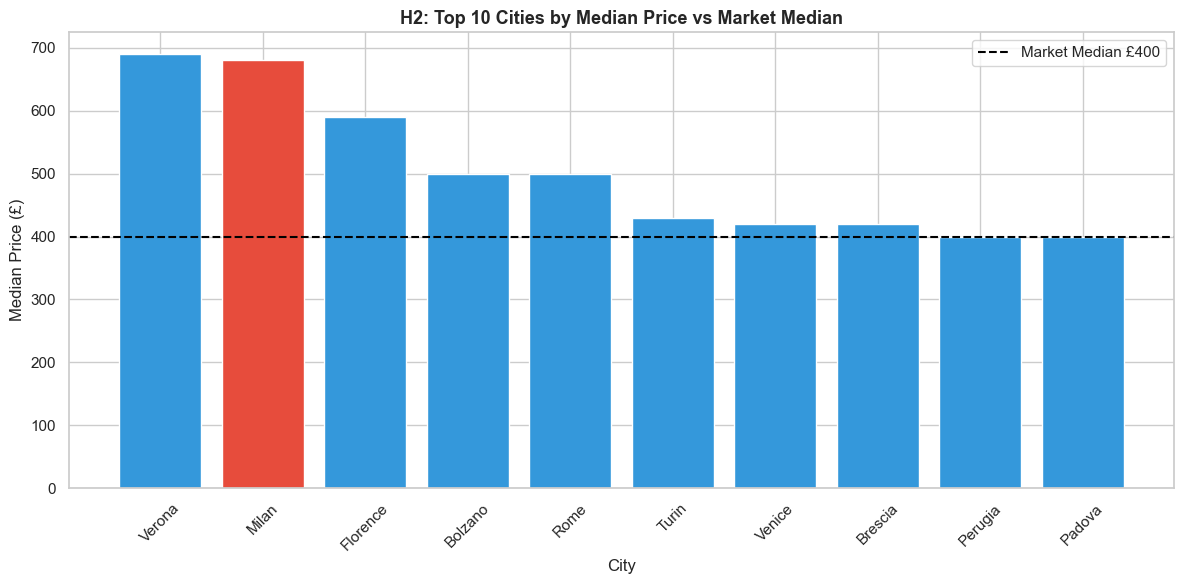

Chart Saved


In [11]:
# Top 10 cities by median price
city_medians = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(city_medians.index, city_medians.values,
                color=['#e74c3c' if c == 'Milan' else '#3498db' for c in city_medians.index])
ax.axhline(y=market_median, color = 'black',linestyle='--',
            linewidth='1.5',label=f'Market Median £{market_median:.0f}')
ax.set_title('H2: Top 10 Cities by Median Price vs Market Median', fontsize= 13, fontweight='bold') 
ax.set_xlabel('City')
ax.set_ylabel('Median Price (£)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/h2_milan_vs_market.png', dpi=150, bbox_inches = 'tight')
plt.show()
print("Chart Saved")                           

## 🧪 H3: Private Rooms vs Studios Price
**Null hypothesis (H0):** Private rooms and studios have the same price
**Alternative hypothesis (H1):** Private rooms are cheaper than studios
**Test:** Mann-Whitney U (one-tailed)
**Why Mann-Whitney:** Non-normal price distribution, two independent groups

In [12]:

private_rooms = df[df['category']=='Private Room']['price'].dropna()
studios = df[df['category']=='Studio']['price'].dropna()

print(f"Private rooms: n={len(private_rooms)}, median=£{private_rooms.median():.2f}")
print(f"studios: n={len(studios)}, median=£{studios.median():.2f}")

Private rooms: n=5196, median=£360.00
studios: n=530, median=£450.00


In [13]:
# Mann-Whitney U (one_tailed: private_rooms < studios)

stat, p_value = stats.mannwhitneyu(private_rooms, studios, alternative='less')

print(f"\nMann-Whitney U statistics: {stat:.2f}")
print(f"P-value (one-tailed): {p_value:.6f}")

if p_value < 0.05:
    print("✅ Result: REJECT H0 — Private rooms are significantly CHEAPER than studios")
else:
    print("❌ Result: FAIL TO REJECT H0 — No significant difference")


Mann-Whitney U statistics: 1068372.50
P-value (one-tailed): 0.000000
✅ Result: REJECT H0 — Private rooms are significantly CHEAPER than studios


#### H3: Visualisation

/var/folders/l4/5kw9_pvj25ddv6lx7lhj71v80000gn/T/ipykernel_1233/2661046019.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x = 'category', y = 'price',
/var/folders/l4/5kw9_pvj25ddv6lx7lhj71v80000gn/T/ipykernel_1233/2661046019.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='category',y='price',


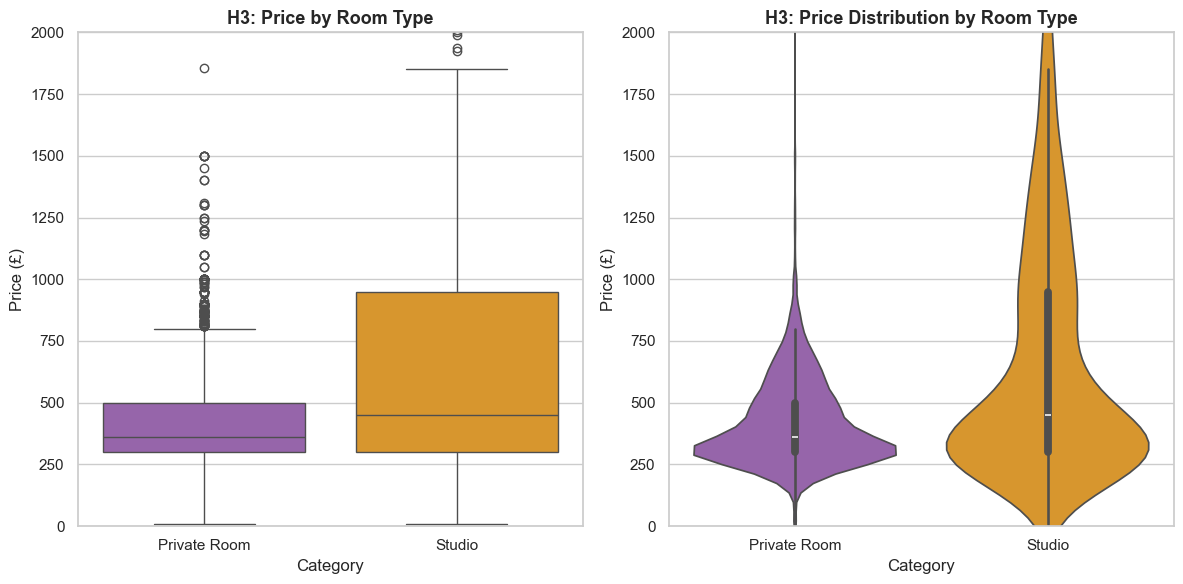

Chart saved.


In [14]:
plot_data = df[df['category'].isin(['Private Room','Studio'])]

fig, axes = plt.subplots(1,2, figsize=(12,6))

# Box plot
sns.boxplot(data=plot_data, x = 'category', y = 'price',
            order=['Private Room', 'Studio'],
            palette = ['#9b59b6', '#f39c12'],
            ax=axes[0])
axes[0].set_title('H3: Price by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Price (£)')
axes[0].set_ylim(0, 2000)

# Violin plot

sns.violinplot(data=plot_data, x='category',y='price',
                order=['Private Room','Studio'],
                palette = ['#9b59b6', '#f39c12'],
                ax=axes[1])
axes[1].set_title('H3: Price Distribution by Room Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Price (£)')
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.savefig('../outputs/h3_private_vs_studio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 📊 Summary of Results

In [15]:
results = pd.DataFrame({
    'Hypothesis':[
        'H1: Furnished > Unfurnished',
        'H2: Milan > Market Median',
        'H3: Private Rooms < Studios'
    ],
    'Test':[
        'Mann-Whitney U',
        'One-sample t-test',
        'Mann Whitney U'
    ],
    'Result': [
        'REJECT H0 ✅' if stats.mannwhitneyu(
            df[df['furnished']=='yes']['price'].dropna(),
            df[df['furnished']=='no']['price'].dropna(),
            alternative='greater').pvalue < 0.05 else 'FAIL TO REJECT ❌',
        'REJECT H0 ✅' if stats.ttest_1samp(
            df[df['city']=='Milan']['price'].dropna(),
            popmean=df['price'].median(),
            alternative='greater').pvalue < 0.05 else 'FAIL TO REJECT ❌',
        'REJECT H0 ✅' if stats.mannwhitneyu(
            df[df['category']=='Private Room']['price'].dropna(),
            df[df['category']=='Studio']['price'].dropna(),
            alternative='less').pvalue < 0.05 else 'FAIL TO REJECT ❌'
    ],
    'Business Insight': [
        'Furnished listings command a price premium',
        'Milan is significantly above market median',
        'Private rooms are cheaper than studios'
    ]
})

print(results.to_string(index=False))

                 Hypothesis              Test      Result                           Business Insight
H1: Furnished > Unfurnished    Mann-Whitney U REJECT H0 ✅ Furnished listings command a price premium
  H2: Milan > Market Median One-sample t-test REJECT H0 ✅ Milan is significantly above market median
H3: Private Rooms < Studios    Mann Whitney U REJECT H0 ✅     Private rooms are cheaper than studios


## 🔍 Key Findings & Business Interpretation

### H1: Furnished vs Unfurnished ✅
- **p-value: 0.000006** — highly significant
- Furnished listings command a measurable price premium
- **Business insight for Lars (RentNest NL):** New landlords entering the Italian market 
  should furnish their properties to maximise rental yield

### H2: Milan vs Market Median ✅  
- **p-value: 0.000000** — extremely significant
- T-statistic: 34.26 — Milan is far above market median
- **Business insight for Priya (NestIndia):** Milan is a premium market — 
  international students and young professionals face significantly higher 
  costs than the national average. Budget planning should account for this gap.

### H3: Private Rooms vs Studios ✅
- **p-value: 0.000000** — extremely significant  
- Private rooms are significantly cheaper than studios
- **Business insight:** For budget-conscious renters, private rooms offer 
  the most affordable entry point into Italian cities

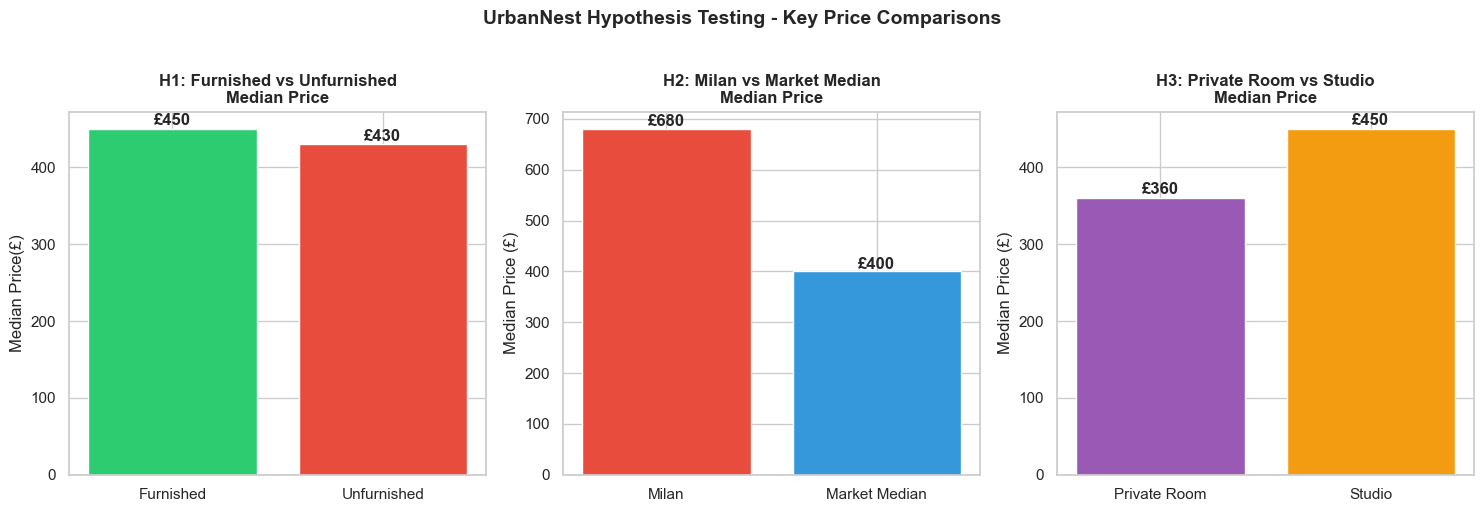

Summary chart saved.


In [16]:
# Summary bar chart of median prices by key segments
fig, axes = plt.subplots(1,3,figsize=(15,5))

# H1 - Furnished vs Unfurnished
h1_data = df[df['furnished'].isin(['yes','no'])].groupby('furnished')['price'].median()
axes[0].bar(['Furnished','Unfurnished'],
            [h1_data.get('yes',0), h1_data.get('no',0)],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('H1: Furnished vs Unfurnished\nMedian Price', fontweight='bold')
axes[0].set_ylabel('Median Price(£)')

for i , v in enumerate([h1_data.get('yes',0), h1_data.get('no',0)]):
    axes[0].text(i, v + 5, f'£{v:.0f}', ha='center',fontweight='bold')

# H2 - Milan vs Market
milan_med = df[df['city']=='Milan']['price'].median()
market_med = df['price'].median()
axes[1].bar(['Milan', 'Market Median'],
            [milan_med, market_med],
            color=['#e74c3c', '#3498db'])
axes[1].set_title('H2: Milan vs Market Median\nMedian Price', fontweight='bold')
axes[1].set_ylabel('Median Price (£)')
for i, v in enumerate([milan_med, market_med]):
    axes[1].text(i , v + 5, f'£{v:.0f}', ha = 'center', fontweight='bold')

# H3 - Private Room vs Studio
h3_data = df[df['category'].isin(['Private Room','Studio'])].groupby('category')['price'].median()
axes[2].bar(['Private Room','Studio'],
            [h3_data.get('Private Room',0),h3_data.get('Studio',0)],
            color=['#9b59b6', '#f39c12']) 
axes[2].set_title('H3: Private Room vs Studio\nMedian Price', fontweight='bold')
axes[2].set_ylabel('Median Price (£)')   
for i , v in enumerate([h3_data.get('Private Room',0), h3_data.get('Studio',0)]):
    axes[2].text(i, v + 5, f'£{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('UrbanNest Hypothesis Testing - Key Price Comparisons',
                fontsize= 14, fontweight='bold', y= 1.02)
plt.tight_layout()
plt.savefig('../outputs/hypothesis_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary chart saved.')